# Schritt 1: Transfer Learning mit VGG19

In diesem Notebook erkunden wir Transfer Learning mit VGG19 in zwei Phasen:

**Phase 1 – VGG19 kennenlernen**: Das vollständige VGG19-Modell laden und
ein eigenes Bild mit den originalen 1.000 ImageNet-Klassen klassifizieren.

**Phase 2 – Transfer Learning vorbereiten**: Den Klassifikationskopf entfernen,
Gewichte einfrieren und einen eigenen Kopf für eine neue Aufgabe anhängen.

## Lernziele

Nach diesem Notebook sollten Sie:

- erklären können, was `include_top=False` bewirkt
- verstehen, warum und wie Gewichte eingefroren werden
- den Anteil trainierbarer vs. eingefrorener Parameter benennen und interpretieren können

## Leitfragen (zum Nachdenken beim Durcharbeiten)

- Warum ist `include_top=False` so wichtig für Transfer Learning?
- Was bewirkt das Einfrieren der Gewichte – und was würde ohne Einfrieren passieren?
- Wie viele Parameter werden tatsächlich trainiert vs. wie viele gibt es insgesamt?
- Warum erreicht Transfer Learning mit wenigen Bildern trotzdem gute Ergebnisse?

# Schritt 2: Pfad-Konfiguration
## Bilddatei zentral definieren

Passen Sie den Pfad zum Beispielbild hier an.

In [1]:
# ── Erste Zelle im Notebook ──
import time
notebook_start = time.time()
print("Notebook gestartet.")

Notebook gestartet.


In [2]:
SAMPLE_IMAGE = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data/teddy.png"

IMG_SIZE = (224, 224)   # Feste Eingabegröße von VGG19

print(f"Bild:      {SAMPLE_IMAGE}")
print(f"Bildgröße: {IMG_SIZE}")

Bild:      /content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data/teddy.png
Bildgröße: (224, 224)


# Schritt 3: Bibliotheken importieren

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Seeds ganz am Anfang setzen
SEED=42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Schritt 4: Google Drive einbinden
## Google Drive mounten

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# ══════════════════════════════════════════════════════
# PHASE 1: VGG19 kennenlernen – Inferenz mit vollem Modell
# ══════════════════════════════════════════════════════

# Schritt 5: Vollständiges VGG19-Modell laden
## VGG19 mit Klassifikationskopf (`include_top=True`)

Wir laden das vollständige VGG19-Modell inklusive des originalen
Klassifikationskopfes für 1.000 ImageNet-Klassen.

Beobachtungsauftrag:
- Wie viele Schichten hat das Modell?
- Was ist die letzte Schicht – und warum hat sie 1.000 Ausgaben?

In [5]:
model_full = tf.keras.applications.VGG19(weights="imagenet", include_top=True)
model_full.summary()
# ▶ Letzte Schicht: Dense(1000, softmax) → 1000 ImageNet-Klassen

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

# Schritt 6: Eigenes Bild mit VGG19 klassifizieren
## Inferenz: Was erkennt VGG19 in unserem Bild?

Wir laden das Beispielbild und lassen VGG19 eine Vorhersage treffen.

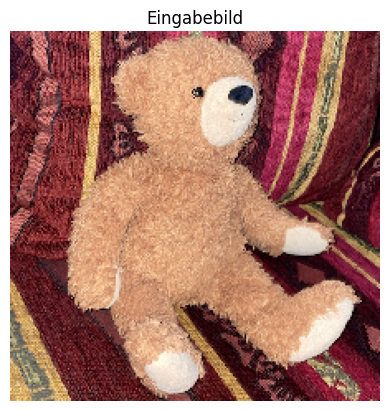

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-5-Vorhersagen des vortrainierten VGG19:
  teddy                         : 85.07%
  mitten                        : 1.64%
  Christmas_stocking            : 1.41%
  Bedlington_terrier            : 1.19%
  seat_belt                     : 1.08%


In [6]:
img = tf.keras.utils.load_img(SAMPLE_IMAGE, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)

plt.imshow(img_array.astype("uint8"))
plt.title("Eingabebild")
plt.axis("off")
plt.show()

# Vorverarbeitung für VGG19 (Normierung + BGR-Konvertierung)
img_preprocessed = tf.keras.applications.vgg19.preprocess_input(img_array)
pred = model_full.predict(img_preprocessed.reshape(1, 224, 224, 3))

top5 = tf.keras.applications.vgg19.decode_predictions(pred, top=5)
print("Top-5-Vorhersagen des vortrainierten VGG19:")
for _, name, prob in top5[0]:
    print(f"  {name:30s}: {prob*100:.2f}%")

# Schritt 7: Beobachtung Phase 1
## Zwischenfazit

VGG19 klassifiziert bereits sehr gut – aber nur aus 1.000 ImageNet-Klassen.

Für eine **eigene Aufgabe** brauchen wir einen angepassten Klassifikationskopf.
Das ist der Kern von Transfer Learning – und genau das bauen wir in Phase 2.

# ══════════════════════════════════════════════════════
# PHASE 2: Transfer Learning – VGG19 anpassen
# ══════════════════════════════════════════════════════

# Schritt 8: VGG19 OHNE Klassifikationskopf laden
## `include_top=False`

Mit `include_top=False` entfernen wir die letzten Dense-Schichten.

Was bleibt: der **Convolutional-Teil** – ein universeller Feature-Extraktor,
der Kanten, Texturen und abstrakte Muster erkennt.

Diese Fähigkeiten sind aufgabenunabhängig und auf neue Probleme übertragbar.

In [7]:
base_model = tf.keras.applications.VGG19(
    weights="imagenet",
    include_top=False,         # ← Klassifikationskopf weglassen
    input_shape=(224, 224, 3)
)
base_model.summary()
# ▶ Letzte Schicht: MaxPooling2D – kein Dense mehr

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

# Schritt 9: Gewichte einfrieren (Feature Extraction)
## Warum einfrieren?

Die VGG19-Gewichte kodieren visuelles Wissen aus 1,2 Mio. Trainingsbildern.
Wir wollen dieses Wissen **behalten** und nur unseren neuen Kopf trainieren.

Ohne Einfrieren würde das Netz das Vorwissen mit einem kleinen Datensatz
überschreiben – bekannt als **Catastrophic Forgetting**.

In [8]:
for layer in base_model.layers:
    layer.trainable = False

trainable_params   = sum(tf.size(w).numpy() for w in base_model.trainable_weights)
untrainable_params = sum(tf.size(w).numpy() for w in base_model.non_trainable_weights)
print(f"Trainierbare Parameter (Basis):   {trainable_params:>10,}")
print(f"Eingefrorene Parameter (Basis):   {untrainable_params:>10,}")

Trainierbare Parameter (Basis):            0
Eingefrorene Parameter (Basis):   20,024,384


# Schritt 10: Eigenen Klassifikationskopf hinzufügen
## Neuer Kopf für unsere Aufgabe

- `GlobalAveragePooling2D` → reduziert Feature-Maps auf einen Vektor
- `Dense(128, relu)` → lernt aufgabenspezifische Kombinationen
- `Dense(1, sigmoid)` → Binärklassifikation: z. B. Teddybär ja / nein

In [9]:
inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(128, activation="relu")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_tl = tf.keras.Model(inputs, outputs)
model_tl.summary()
# ▶ Trainable params ≪ Non-trainable params

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,090,177 (76.64 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

# Schritt 11: Manuelle Parameterberechnung
## Parameter des neuen Kopfes nachrechnen

`GlobalAveragePooling2D` gibt bei VGG19 einen Vektor der Länge **512** aus
(Anzahl der Filter im letzten Conv-Block).

Für jeden Dense-Layer gilt:
`Parameter = Eingaben × Neuronen + Neuronen (Biases)`

In [10]:
# Neuer Kopf: GlobalAvgPool(512) → Dense(128) → Dense(1)
params_dense1 = 512 * 128 + 128
params_dense2 = 128 * 1   + 1
total_head    = params_dense1 + params_dense2

print("=== Manuelle Parameterberechnung: Neuer Kopf ===")
print(f"Dense(128):  512 × 128 + 128 = {params_dense1:>8,}")
print(f"Dense(1):    128 ×   1 +   1 = {params_dense2:>8,}")
print(f"{'─' * 42}")
print(f"Kopf gesamt:                   {total_head:>8,}")
print()

total_params     = model_tl.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model_tl.trainable_weights)
frozen_params    = total_params - trainable_params

print("=== Parametervergleich (gesamt) ===")
print(f"Gesamt-Parameter:        {total_params:>12,}")
print(f"Trainierbare Parameter:  {trainable_params:>12,}  ({trainable_params/total_params*100:.1f} %)")
print(f"Eingefrorene Parameter:  {frozen_params:>12,}  ({frozen_params/total_params*100:.1f} %)")
print()
print(f"Prüfung: manuell = {total_head:,}  ≈  automatisch = {trainable_params:,}  ✓")
print()
print("Fazit: Wir würden weniger als 1 % der Parameter trainieren –")
print("       und könnten trotzdem sehr gute Ergebnisse erzielen!")

=== Manuelle Parameterberechnung: Neuer Kopf ===
Dense(128):  512 × 128 + 128 =   65,664
Dense(1):    128 ×   1 +   1 =      129
──────────────────────────────────────────
Kopf gesamt:                     65,793

=== Parametervergleich (gesamt) ===
Gesamt-Parameter:          20,090,177
Trainierbare Parameter:        65,793  (0.3 %)
Eingefrorene Parameter:    20,024,384  (99.7 %)

Prüfung: manuell = 65,793  ≈  automatisch = 65,793  ✓

Fazit: Wir würden weniger als 1 % der Parameter trainieren –
       und könnten trotzdem sehr gute Ergebnisse erzielen!


# Schritt 12: Modell kompilieren
## Bereit für das Training

Das Modell ist kompiliert und bereit. Für ein echtes Training würden
Trainingsdaten in der Ordnerstruktur `train/teddy/` und `train/no_teddy/`
benötigt.

- `binary_crossentropy` als Loss (Binärklassifikation)
- Niedrige Lernrate `1e-4` – da nur der kleine Kopf trainiert wird

In [11]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
print("Modell kompiliert ✓")
print("Bereit für model.fit() – sobald Trainingsdaten vorhanden sind.")

Modell kompiliert ✓
Bereit für model.fit() – sobald Trainingsdaten vorhanden sind.


# Schritt 13: Arbeitsauftrag
## Reflexionsfragen – bitte schriftlich beantworten

1. **Warum ist `include_top=False` so wichtig für Transfer Learning?**
   Tipp: Was enthält der „Top" – und für welche Aufgabe wurde er trainiert?

2. **Was bewirkt das Einfrieren der Gewichte (`layer.trainable = False`)?**
   Was würde passieren, wenn wir die Basis **nicht** einfrieren?

3. **Wie viele Parameter werden tatsächlich trainiert vs. wie viele gibt es insgesamt?**
   Interpretieren Sie das Ergebnis aus Schritt 11.

# Schritt 14: Musterantworten *(nur Dozenten-Version)*

---

## Frage 1: Warum ist `include_top=False` so wichtig?

Der „Top" enthält die letzten Dense-Layer, die auf genau 1.000 ImageNet-Klassen
trainiert wurden – er kann keine eigenen Klassen ausgeben.

Mit `include_top=False` behalten wir nur den Convolutional-Teil: einen universellen
Feature-Extraktor für Kanten, Texturen und abstrakte Muster – aufgabenunabhängig
und auf neue Probleme übertragbar.

**Merksatz:** `include_top=False` trennt das *Sehen* (Convolutional-Teil) vom
*Entscheiden* (Klassifikationskopf). Wir behalten das Sehen und ersetzen das Entscheiden.

---

## Frage 2: Was bewirkt das Einfrieren der Gewichte?

`layer.trainable = False` verhindert, dass Backpropagation die Gewichte verändert.

- **Bewahrung des Vorwissens**: Ohne Einfrieren würde ein kleiner Datensatz das
  erlernte Wissen überschreiben (*Catastrophic Forgetting*).
- **Effizienz**: Nur ~65.000 statt ~14,8 Mio. Parameter werden berechnet –
  das Training ist drastisch schneller und benötigt viel weniger Daten.

**Merksatz:** Einfrieren schützt das Vorwissen und fokussiert das Training auf das Neue.

---

## Frage 3: Parameteranteil

| | Parameter | Anteil |
|---|---|---|
| Gesamt | ~14.849.345 | 100 % |
| Trainierbar (Kopf) | ~65.793 | ~0,4 % |
| Eingefroren (Basis) | ~14.783.552 | ~99,6 % |

Wir trainieren weniger als 0,5 % der Parameter – und erzielen trotzdem sehr gute
Ergebnisse, weil die restlichen 99,6 % bereits sinnvoll vorbelegt sind.

**Merksatz:** Transfer Learning ist effizient, weil fast alles Wissen schon vorhanden ist –
wir passen nur die letzte Meile an.

# Schritt 15: Merksatz
## Merksatz

**Transfer Learning ist heute der Standard in der Praxis –
niemand trainiert große Netze von Grund auf.**

- `include_top=False` trennt Feature-Extraktor vom Klassifikationskopf
- Einfrieren verhindert Catastrophic Forgetting
- Wir trainieren < 1 % der Parameter und erzielen trotzdem hohe Accuracy
- Training dauert Minuten statt Wochen

Ausblick: Im nächsten Notebook (InceptionV3) vergleichen wir eine
effizientere Architektur mit weniger Parametern bei ähnlicher Leistung.

In [12]:
# ── Letzte Zelle im Notebook ──
total = time.time() - notebook_start
minuten = int(total // 60)
sekunden = int(total % 60)
print(f"Gesamtlaufzeit: {minuten} min {sekunden} sek")

Gesamtlaufzeit: 0 min 39 sek
